# Rate-Distortion Curve plotting from W&B Project

---


#### Imports and global settings


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wandb
from omegaconf import OmegaConf, DictConfig
from pathlib import Path
from pprint import pprint
import json


# Quick ANSI color code shortcurts
r = "\033[31m"
y = "\033[33m"
g = "\033[32m"
b = "\033[34m"
e = "\033[0m"

api = wandb.Api()
# Project is specified by <entity/project-name>
entity: str = "cedric-leonard"
project: str = "SAR_DDC_FPGA"  # "SAR_DDC-RD-curve"
runs = api.runs(f"{entity}/{project}")
nb_all_runs = len(runs)
print(f"{b}Found {nb_all_runs} runs in project {entity}/{project}{e}")

path_to_csv_results = Path("../data/RD-curve_results/test1.csv")

verbose = False
save_loaded_project = False

Found 217 runs in project cedric-leonard/SAR_DDC_FPGA


#### Config loading


In [2]:
run_name_list, id_list, summary_list, config_list = [], [], [], []
data_name_list, model_name_list, lmbda_list, seed_list = [], [], [], []
no_output_padding_list = []

for i, run in enumerate(runs):
    # Transform the wandb config in a DictConfig object (to be able to easily access nested keys)
    config = OmegaConf.create(run.config)

    run_name_list.append(run.name)  # .name is the human-readable name of the run.
    id_list.append(run.id)  # .id is the unique id of the run (used in logs and the URL).
    # .summary contains the output keys/values for metrics like accuracy. We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    if verbose and i == 0:
        print(f"Run N°{i} ({r}{run.id}{e}, '{run.name}') summary:")
        # print(f"BPP of Run N°{i} = {summary_list[i]['test/bpp']} and its config:")
        pprint(run.config)
        pprint(summary_list[i])
        # pprint(run.history())

    # Store the model name, lmbda (rate-distortion tradeoff) and the seed in separate lists (for easier access)
    dl_model_name = OmegaConf.select(config, "model.net._target_").split(".")[-1]
    prefix = run.name.split("_")[0]
    activation_name = OmegaConf.select(config, "model.net.activation")

    model_name_list.append(f"{dl_model_name}_{activation_name}")
    lmbda_list.append(OmegaConf.select(config, "model.criterion.lmbda"))
    seed_list.append(OmegaConf.select(config, "seed"))
    # Get the dataset name from the config "data._target_" last part (after the last dot)
    data_name_list.append(
        OmegaConf.select(config, "data._target_").split(".")[-1]
    )  # e.g., EuroSATRGBDataModule or EuroSATSARDataModule
    no_output_padding_list.append(OmegaConf.select(config, "model.net.no_output_padding"))

    #  Store the full config (just in case), remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items()})  # if not k.startswith("_")})

# print(f"{len(model_name_list)=}, {len(lmbda_list)=}, {len(seed_list)=}, {len(config_list)=}")

# Create a dataframe with all the information
raw_runs_df = pd.DataFrame(
    {
        "id": id_list,
        "run_name": run_name_list,
        "data_name": data_name_list,
        "model_name": model_name_list,
        "lmbda": lmbda_list,
        "seed": seed_list,
        "no_output_padding": no_output_padding_list,
        "summary": summary_list,
        "config": config_list,
    }
)

# Set the index of the datafrane to be the run id
raw_runs_df.set_index("id", inplace=True)

# Save the dataframe to a csv file
if save_loaded_project:
    csv_file_path = f"{project}.csv"
    raw_runs_df.to_csv(csv_file_path)
    print(f"Dataframe saved to {b}{csv_file_path}{e}")
print(f"Project {b}{project}{e} contains {r}{nb_all_runs}{e} runs.")

Project SAR_DDC_FPGA contains 217 runs.


## Filtering / Run cleaning

_This part is super **specific** and should probably be checked/changed everytime the goal of this script is different_


In [3]:
def print_runs_info(df: pd.DataFrame, columns: list[str]):
    for i, row in df.iterrows():
        # Don't start newline
        print(f"  - Run {i:<8} {row['run_name']:<50}:", end="")
        for col in columns:
            print(f" {r}{col}={row[col]}{e},", end="")
        print()


# ----- Remove runs run without a specific seed -----
# print all the runs that will be removed due to seed filtering
print(f"{b}Removing runs whose seed is not in [0, 1, 2, 3, 4, 5, 6])...{e}")
print_runs_info(raw_runs_df[~raw_runs_df["seed"].isin([0, 1, 2, 3, 4, 5, 6])], ["seed"])
runs_df = raw_runs_df[
    raw_runs_df["seed"].isin([0, 1, 2, 3, 4, 5, 6])
]  # The GTs (ADAM-NOC and MERLIN) use seed = 42

# ----- Remove runs with "debug" tags in the config -----
print(f"{b}Removing runs with 'debug' tags in the config...{e}")
debug_runs = runs_df[runs_df["config"].apply(lambda x: "debug" in x["tags"])]
if debug_runs.shape[0] > 0:
    print_runs_info(debug_runs, ["config"])
runs_df = runs_df[~runs_df["config"].apply(lambda x: "debug" in x["tags"])]
# ----- Remove runs with "crashed" tags in the config -----
print(f"{b}Removing runs with 'crashed' tags in the config...{e}")
crashed_runs = runs_df[runs_df["config"].apply(lambda x: "crashed" in x["tags"])]
if crashed_runs.shape[0] > 0:
    print_runs_info(crashed_runs, ["config"])
runs_df = runs_df[~runs_df["config"].apply(lambda x: "crashed" in x["tags"])]

# -----Remove runs that do not have a "test/psnr" key in the summary ("crashed run") -----
print(f"{b}Removing runs without 'test/bpp' in the summary...{e}")
no_bpp_runs = runs_df[~runs_df["summary"].apply(lambda x: "test/bpp" in x.keys())]
if no_bpp_runs.shape[0] > 0:
    print_runs_info(no_bpp_runs, ["summary"])
runs_df = runs_df[runs_df["summary"].apply(lambda x: "test/bpp" in x.keys())]

# ----- Filter out runs whose run_name does not start by "ResSHyp"-----
print(f"{b}Removing runs whose run_name does not start by 'ResSHyp'...{e}")
print_runs_info(runs_df[~runs_df["run_name"].str.startswith("ResSHyp")], [])
runs_df = runs_df[runs_df["run_name"].str.startswith("ResSHyp")]

# ----- Filter runs with "diverging"/"unnecessary" lmbda values -----
print(f"{b}Removing runs with 'diverging'/'unnecessary' lmbda values (0.25, 0.5 and 1.5)...{e}")
diverging_lmbda_runs = runs_df[runs_df["lmbda"].isin([0.25, 0.5, 1.5])]
if diverging_lmbda_runs.shape[0] > 0:
    print_runs_info(diverging_lmbda_runs, ["lmbda"])
runs_df = runs_df[~runs_df["lmbda"].isin([0.25, 0.5, 1.5])]
# runs_df = runs_df[runs_df["lmbda"].isin([0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500])]

# ---- Remove runs with "gdn1" activations -----
print(f"{b}Removing runs with 'gdn1' activations...{e}")
gdn1_runs = runs_df[runs_df["model_name"].str.contains("gdn1")]
if gdn1_runs.shape[0] > 0:
    print_runs_info(gdn1_runs, ["model_name"])
runs_df = runs_df[~runs_df["model_name"].str.contains("gdn1")]

# ----- Print the remaining runs ----- #
nb_filtered_runs = len(runs_df)
print(
    f"{r}{nb_all_runs - nb_filtered_runs}{e} runs were filtered out, {g}{nb_filtered_runs}{e} runs were kept."
)

Removing runs whose seed is not in [0, 1, 2, 3, 4, 5, 6])...
  - Run ui48mk6u MERLIN_GT                                         : seed=42,
  - Run yk8uatcm ADAM-NOC_GT                                       : seed=42,
  - Run bx6zfbqn ResSHyp-gdn_10_merlinʎ200_lr5e-05_b12_no_out_pad  : seed=10,
  - Run ofdw7g4p ResSHyp-gdn_10_merlinʎ100_lr5e-05_b12_no_out_pad  : seed=10,
Removing runs with 'debug' tags in the config...
Removing runs with 'crashed' tags in the config...
Removing runs without 'test/bpp' in the summary...
Removing runs whose run_name does not start by 'ResSHyp'...
Removing runs with 'diverging'/'unnecessary' lmbda values (0.25, 0.5 and 1.5)...
Removing runs with 'gdn1' activations...
  - Run ntgnuk34 ResSHyp-gdn1_0_merlinʎ10_lr5e-05_b12_no_out_pad   : model_name=ResidualScaleHyperpriorPatched_gdn1,
5 runs were filtered out, 212 runs were kept.


In [4]:
# --- Print unique model, lambda and seed per dataset ---
for i, name in enumerate(runs_df["data_name"].unique()):
    dataset_runs = runs_df[runs_df["data_name"] == name]
    unique_models = dataset_runs["model_name"].unique()
    unique_lmbda = dataset_runs["lmbda"].unique()
    unique_seeds = dataset_runs["seed"].unique()
    unique_no_output_padding = dataset_runs["no_output_padding"].unique()
    print(
        f"{r}{name}{e} ({g}{len(dataset_runs)}{e}) unique:\n"
        f"\t-  models: {g}{len(unique_models)}{e}, {unique_models}\n"
        f"\t- no_output_padding: {g}{len(unique_no_output_padding)}{e}, {unique_no_output_padding}\n"
        f"\t-  lambda: {g}{len(unique_lmbda)}{e}, {sorted(unique_lmbda.astype(float).tolist())}\n"
        f"\t-   seeds: {g}{len(unique_seeds)}{e}, {sorted(unique_seeds.astype(int).tolist())}\n"
    )
    expected_nb_runs = (
        len(unique_models) * len(unique_lmbda) * len(unique_seeds) * len(unique_no_output_padding)
    )
    if len(dataset_runs) != expected_nb_runs:
        print(
            f"   {y}Warning{e}: for all the unique values {b}{expected_nb_runs}{e} where expected! {b}{expected_nb_runs - len(dataset_runs)}{e} are missing.\n"
        )

# Print all run hierarchically grouped by dataset, model, no_output_padding, lmbda, seed
for dataset in runs_df["data_name"].unique():
    dataset_runs = runs_df[runs_df["data_name"] == dataset]
    print(f"{b}Dataset: {dataset}{e}")
    for model in dataset_runs["model_name"].unique():
        model_runs = dataset_runs[dataset_runs["model_name"] == model]
        print(f"  {g}Model: {model}{e}")
        for no_output_padding in model_runs["no_output_padding"].unique():
            no_output_padding_runs = model_runs[
                model_runs["no_output_padding"] == no_output_padding
            ]
            print(f"    {b}No_output_padding: {no_output_padding}{e}")
            for lmbda in sorted(no_output_padding_runs["lmbda"].unique().astype(float).tolist()):
                lmbda_runs = no_output_padding_runs[no_output_padding_runs["lmbda"] == lmbda]
                print(f"      {r}Lambda: {lmbda}{e}")
                for seed in sorted(lmbda_runs["seed"].unique().astype(int).tolist()):
                    seed_runs = lmbda_runs[lmbda_runs["seed"] == seed]
                    for run_id in seed_runs.index:
                        print(f"        Seed: {seed} -> Run ID: {run_id}")

# Print the run_ids of the run with "data_name" == "EuroSATSARDataModule" and "model_name" == "mbt2018"
# print(
#     list(
#         runs_df[
#             (runs_df["data_name"] == "EuroSATSARDataModule")
#             & (runs_df["model_name"] == "mbt2018")
#         ].index
#     )
# )

TSXSSCDataModule (212) unique:
	-  models: 2, ['ResidualScaleHyperpriorPatched_gdn'
 'ResidualScaleHyperpriorPatched_relu']
	- no_output_padding: 2, [True False]
	-  lambda: 10, [1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
	-   seeds: 6, [0, 1, 2, 3, 4, 5]


Dataset: TSXSSCDataModule
  Model: ResidualScaleHyperpriorPatched_gdn
    No_output_padding: True
      Lambda: 1.0
        Seed: 0 -> Run ID: ekgygjse
        Seed: 1 -> Run ID: f40akucm
        Seed: 2 -> Run ID: 58r6xgte
        Seed: 3 -> Run ID: ok26nzg1
        Seed: 4 -> Run ID: sfh6nxs4
      Lambda: 2.0
        Seed: 0 -> Run ID: ptuyulj7
        Seed: 1 -> Run ID: qoi4ivp8
        Seed: 2 -> Run ID: db4vmcpz
        Seed: 3 -> Run ID: mg9jdmfi
        Seed: 4 -> Run ID: o3uf6zie
      Lambda: 5.0
        Seed: 0 -> Run ID: g6hd41od
        Seed: 1 -> Run ID: mc690npb
        Seed: 2 -> Run ID: icjuqqz0
        Seed: 3 -> Run ID: 1i4v5jgo
        Seed: 4 -> Run ID: 1o1usv3o
      Lambda: 10.0
        Seed

#### Group and statistics


In [5]:
verbose = False

# --- List of specific metrics to track for each model ---
metrics_of_interest = ["test/bpp"]
for metric in ["psnr", "ssim", "ms_ssim"]:  # "mse"
    metrics_of_interest.append(f"test/{metric}")
    metrics_of_interest.append(f"test/{metric}_merlin")
    metrics_of_interest.append(f"test/{metric}_adam_noc")
statistics_of_interest = ["mean", "min", "max", "std"]
metrics_to_track = []
for metric in metrics_of_interest:
    for stat in statistics_of_interest:
        metrics_to_track.append(f"{metric} {stat}")
print(f"Number of metrics to track: {len(metrics_to_track)}")

model_statistics = {}
# --- For each dataset ---
for data_name, df_data in runs_df.groupby("data_name"):
    # Append the list of metrics to track to the dictionanry
    model_statistics[data_name] = {}
    # --- For each model ---
    for (model_name, no_output_padding), df_model in df_data.groupby(
        ["model_name", "no_output_padding"]
    ):
        print(
            f"Processing dataset {data_name}, model {model_name} (no_output_padding={no_output_padding})..."
        )
        # Create an empty dataframe that will contain a column for each metric (test/psnr, test/bpp) and a row for each lmbda value
        lmbda_values = df_model["lmbda"].unique()
        stats_dataframe = pd.DataFrame(index=lmbda_values, columns=metrics_to_track)
        stats_dataframe.sort_index(inplace=True)  # Sort the index (only useful for nicer logs)

        # Compute a dictionnary of statistics (mean, min, max, std) for the metric 'test/psnr' and 'test/bpp' in summary, for all the models having the same lmbda (therefore having different seeds)
        # Each dictionnary will have 2 keys 'test/psnr' and 'test/bpp' that will each contain another dictionnary  made of the statistics (mean, min, max, std)
        # Compute this for each lmbda value and add it to a Pandas Serie using the lmbda value as the index
        stats = {}
        for lmbda, df_lmbda in df_model.groupby("lmbda"):
            # Compute the statistics for the 'test/psnr' and 'test/bpp' metrics
            for metric in metrics_of_interest:
                for stat in statistics_of_interest:
                    stats_dataframe.loc[(lmbda, f"{metric} {stat}")] = getattr(
                        df_lmbda["summary"].apply(lambda x: x[metric]),
                        stat,
                    )()

        if verbose:  # and model_name == "bmshj2018-factorized":
            pprint(stats_dataframe)

        model_name = f"{model_name}{'' if no_output_padding else '_out_pad'}"

        model_statistics[data_name][model_name] = stats_dataframe

Number of metrics to track: 40
Processing dataset TSXSSCDataModule, model ResidualScaleHyperpriorPatched_gdn (no_output_padding=False)...
Processing dataset TSXSSCDataModule, model ResidualScaleHyperpriorPatched_gdn (no_output_padding=True)...
Processing dataset TSXSSCDataModule, model ResidualScaleHyperpriorPatched_relu (no_output_padding=False)...
Processing dataset TSXSSCDataModule, model ResidualScaleHyperpriorPatched_relu (no_output_padding=True)...

## Save into a CSV file

In [6]:
# for each model append a single csv file with the statistics
with open(path_to_csv_results, "w") as f:
    f.write("data_name,model_name,lmbda," + ",".join(metrics_to_track) + "\n")
    for data_name, models in model_statistics.items():
        for model_name, stats_df in models.items():
            for lmbda, row in stats_df.iterrows():
                f.write(
                    f"{data_name},{model_name},{lmbda},"
                    + ",".join([str(x) for x in row.values])
                    + "\n"
                )
print(f"Statistics saved to {b}{path_to_csv_results}{e}")

Statistics saved to ../data/RD-curve_results/test1.csv


# Plots RD-curves 

In [12]:
colors = {"with_out_pad": "tab:blue", "no_out_pad": "tab:red"}  # tab:red
linestyles = {"gdn": "dotted", "relu": "solid"}  # "gdn1": "dashed",


def plot_psnr_bpp_curve(ax, bpp_mean: float, psnr_mean: float, linestyle: str, color: str):
    ax.plot(
        bpp_mean,
        psnr_mean,
        "o",
        linestyle=linestyle,
        color=color,
        # label=f"{model_name} {ref}",
    )


def add_psnr_error_bands(ax, bpp_mean: float, psnr_min: float, psnr_max: float, color: str):
    ax.fill_between(
        bpp_mean,
        psnr_max,
        psnr_min,
        alpha=0.2,
        color=color,
    )


def add_bpp_error_bars(ax, bpp_mean: float, psnr_mean: float, bpp_std: float):
    ax.errorbar(
        bpp_mean,
        psnr_mean,
        xerr=bpp_std,
        fmt="none",
        ecolor="black",
        capsize=2,  # Set the size of the vertical lines at the end of the error bars
    )


def add_lambda_labels(ax, model_name: str, ref: str):
    # Add text labels for each lmbda value
    for model in model_statistics["TSXSSCDataModule"]:
        if model == model_name:
            for lmbda, row in model_statistics["TSXSSCDataModule"][model_name].iterrows():
                ax.text(
                    row["test/bpp mean"] + 0.05,
                    row[f"test/{ref} mean"],
                    f"{int(lmbda)}",
                    ha="center",
                    va="bottom",
                )


def add_legend(ax, colors: dict[str, str], linestyles: dict[str, str]):
    for key, value in colors.items():
        ax.plot([], [], color=value, label=f"{key}")
    for key, value in linestyles.items():
        ax.plot([], [], color="black", linestyle=value, label=f"{key}")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="lower right")

#### Plot the rate distorion curves


Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_gdn_out_pad...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_gdn...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_relu_out_pad...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_relu...


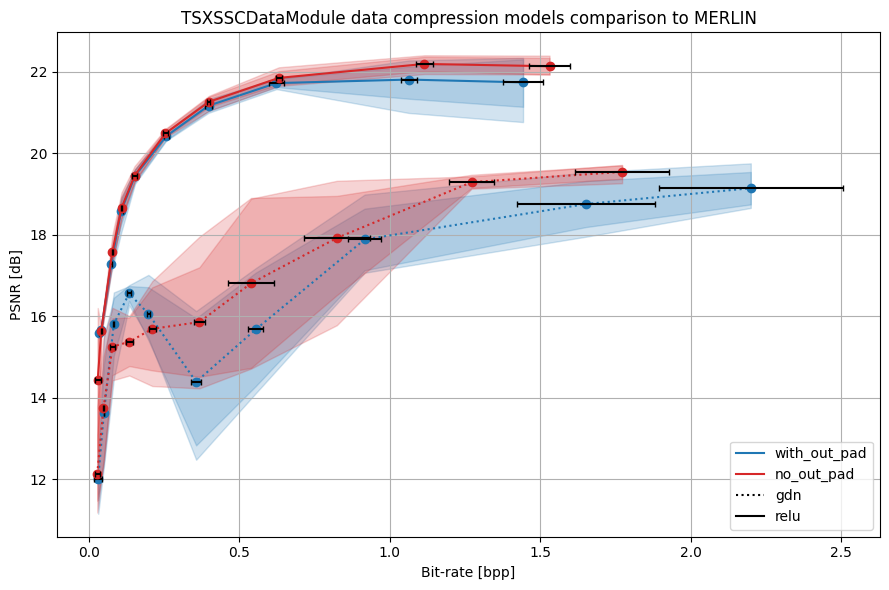

In [ ]:
ref = "psnr_merlin"
fig, ax = plt.subplots(figsize=(9, 6))

for j, model_name in enumerate(model_statistics["TSXSSCDataModule"]):
    print(
        f"Plotting {model_statistics['TSXSSCDataModule'][model_name].shape[0]} lmbda values for model {model_name}..."
    )
    color = colors["with_out_pad"] if "out_pad" in model_name else colors["no_out_pad"]
    # Set linestyle based on activation
    linestyle = linestyles[model_name.split("_")[1]]

    bpp_mean = model_statistics["TSXSSCDataModule"][model_name]["test/bpp mean"].astype(float)
    bpp_std = model_statistics["TSXSSCDataModule"][model_name]["test/bpp std"].astype(float)
    psnr_mean = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} mean"].astype(float)
    psnr_std = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} std"].astype(float)
    psnr_min = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} min"].astype(float)
    psnr_max = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} max"].astype(float)
    plot_psnr_bpp_curve(ax, bpp_mean, psnr_mean, linestyle, color)
    add_psnr_error_bands(ax, bpp_mean, psnr_min, psnr_max, color)
    # add_psnr_error_bands(ax, bpp_mean, psnr_mean - psnr_std, psnr_mean + psnr_std, color)
    add_bpp_error_bars(ax, bpp_mean, psnr_mean, bpp_std)


# add_lambda_labels(ax, "ResidualScaleHyperpriorPatched_gdn_out_pad", ref)
# add_lambda_labels(ax, "ResidualScaleHyperpriorPatched_relu", ref)

ax.set_title("TSXSSCDataModule data compression models comparison to MERLIN")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("PSNR [dB]")
ax.grid()
add_legend(ax, colors, linestyles)
plt.tight_layout()
plt.show()

Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_gdn_out_pad...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_gdn...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_relu_out_pad...
Plotting 10 lmbda values for model ResidualScaleHyperpriorPatched_relu...


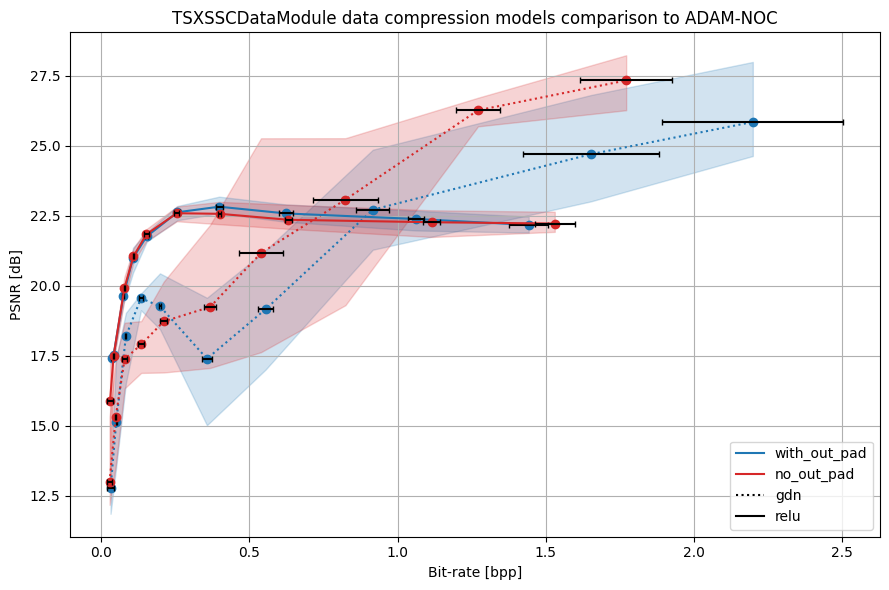

In [14]:
ref = "psnr_adam_noc"
fig, ax = plt.subplots(figsize=(9, 6))

for j, model_name in enumerate(model_statistics["TSXSSCDataModule"]):
    print(
        f"Plotting {model_statistics['TSXSSCDataModule'][model_name].shape[0]} lmbda values for model {model_name}..."
    )
    color = colors["with_out_pad"] if "out_pad" in model_name else colors["no_out_pad"]
    # Set linestyle based on activation
    linestyle = linestyles[model_name.split("_")[1]]

    bpp_mean = model_statistics["TSXSSCDataModule"][model_name]["test/bpp mean"].astype(float)
    bpp_std = model_statistics["TSXSSCDataModule"][model_name]["test/bpp std"].astype(float)
    psnr_mean = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} mean"].astype(float)
    psnr_std = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} std"].astype(float)
    psnr_min = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} min"].astype(float)
    psnr_max = model_statistics["TSXSSCDataModule"][model_name][f"test/{ref} max"].astype(float)
    plot_psnr_bpp_curve(ax, bpp_mean, psnr_mean, linestyle, color)
    add_psnr_error_bands(ax, bpp_mean, psnr_min, psnr_max, color)
    add_bpp_error_bars(ax, bpp_mean, psnr_mean, bpp_std)


# add_lambda_labels(ax, "ResidualScaleHyperpriorPatched_gdn_out_pad", ref)
# add_lambda_labels(ax, "ResidualScaleHyperpriorPatched_relu", ref)

ax.set_title("TSXSSCDataModule data compression models comparison to ADAM-NOC")
ax.set_xlabel("Bit-rate [bpp]")
ax.set_ylabel("PSNR [dB]")
ax.grid()
add_legend(ax, colors, linestyles)
plt.tight_layout()
plt.show()